# Reproduce Sepsyd best configuration with Explainable AI

Notebook này tái tạo cấu hình chính thức của Sepsyd: **XGBoost, H=5, Base + Mask**, sau đó giải thích model bằng exact TreeSHAP của XGBoost.

Kết quả gồm bảng metric và toàn bộ biểu đồ XAI hiển thị trực tiếp trong notebook.

In [3]:
%uv pip install -q "xgboost>=3.0,<4" "shap>=0.47,<1" "scikit-learn>=1.5,<2"

/usr/bin/python3.11: No module named uv
Note: you may need to restart the kernel to use updated packages.


## 1. Environment and paths

In [ ]:
from __future__ import annotations

import gc
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupKFold

SEED = 42
np.random.seed(SEED)

VOLUME_ROOT = Path("/mnt/early-sepsis-xai")
INPUT_ZIP = VOLUME_ROOT / "training.zip"
WORK_DIR = Path("/tmp/early-sepsis-xai")
RAW_DIR = WORK_DIR / "raw"

RAW_DIR.mkdir(parents=True, exist_ok=True)

if not INPUT_ZIP.is_file():
    raise FileNotFoundError(f"Upload training.zip to {INPUT_ZIP}")

HISTORY_HOURS = 5
N_SPLITS = 10
GLOBAL_SAMPLE_SIZE = 10_000
DEVICE = "cuda"

print(f"XGBoost {xgb.__version__} | SHAP {shap.__version__}")
print(f"Dataset source: {INPUT_ZIP}")

## 2. Extract and index patient files

Mỗi file `.psv` là chuỗi thời gian của một bệnh nhân. Chỉ giữ một file cho mỗi `patient_id`.

In [ ]:
def extract_dataset(zip_path: Path, destination: Path) -> None:
    marker = destination / ".complete"
    if marker.exists():
        return
    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(destination)
    marker.touch()


def classify_source(patient_id: str) -> str:
    return "A" if int(patient_id[1:]) < 100_000 else "B"


def index_patient_files(root: Path) -> list[tuple[str, Path, str]]:
    records = []
    seen = set()
    for path in sorted(root.rglob("*.psv")):
        patient_id = path.stem
        if patient_id in seen:
            continue
        seen.add(patient_id)
        records.append((patient_id, path, classify_source(patient_id)))
    return records


extract_dataset(INPUT_ZIP, RAW_DIR)
patient_records = index_patient_files(RAW_DIR)
if len(patient_records) != 40_336:
    raise ValueError(f"Expected 40,336 patients, found {len(patient_records):,}")

source_counts = pd.Series([source for _, _, source in patient_records]).value_counts().sort_index()
print(f"Indexed {len(patient_records):,} patients")
display(source_counts.rename("patients").to_frame())

Indexed 40,336 patients


,patients
A,20336
B,20000


## 3. Preprocessing

Giữ đúng pipeline best-config: signed `log1p` cho 25 biến lệch, z-score normalization, sau đó LOCF theo từng bệnh nhân. Missing mask được tạo trước imputation.

In [ ]:
VITAL_SIGNS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]
LABS = [
    "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN",
    "Alkalinephos", "Calcium", "Chloride", "Creatinine", "Bilirubin_direct",
    "Glucose", "Lactate", "Magnesium", "Phosphate", "Potassium",
    "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT", "WBC",
    "Fibrinogen", "Platelets",
]
DEMOGRAPHICS = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]
CLINICAL_VARS = VITAL_SIGNS + LABS + DEMOGRAPHICS
MASKED_VARS = VITAL_SIGNS + LABS

LOG_TRANSFORM_VARS = [
    "FiO2", "WBC", "HospAdmTime", "Alkalinephos", "AST", "TroponinI",
    "Bilirubin_total", "Creatinine", "O2Sat", "ICULOS", "Bilirubin_direct",
    "PTT", "Lactate", "Glucose", "BUN", "SaO2", "Magnesium",
    "Platelets", "Potassium", "Phosphate", "Calcium", "Fibrinogen",
    "PaCO2", "DBP", "MAP",
]

BASE_FEATURE_NAMES = CLINICAL_VARS + [f"{name}_mask" for name in MASKED_VARS]
FEATURE_NAMES = [
    f"{name}_t0" if lag == 0 else f"{name}_t-{lag}"
    for lag in range(HISTORY_HOURS)
    for name in BASE_FEATURE_NAMES
]
FEATURES_PER_HOUR = len(BASE_FEATURE_NAMES)

assert len(CLINICAL_VARS) == 40
assert len(MASKED_VARS) == 34
assert len(FEATURE_NAMES) == 370

In [ ]:
def signed_log1p(frame: pd.DataFrame) -> pd.DataFrame:
    transformed = frame.copy()
    for column in LOG_TRANSFORM_VARS:
        values = transformed[column]
        transformed[column] = np.sign(values) * np.log1p(np.abs(values))
    return transformed


def fit_normalization_stats(
    records: list[tuple[str, Path, str]],
) -> tuple[dict[str, dict[str, float]], dict[str, int]]:
    count = np.zeros(len(CLINICAL_VARS), dtype=np.int64)
    total = np.zeros(len(CLINICAL_VARS), dtype=np.float64)
    squared_total = np.zeros(len(CLINICAL_VARS), dtype=np.float64)
    row_counts = {}

    for patient_id, path, _ in records:
        raw = pd.read_csv(path, sep="|")
        row_counts[patient_id] = len(raw)
        values = signed_log1p(raw[CLINICAL_VARS]).to_numpy(dtype=np.float64)
        count += np.sum(~np.isnan(values), axis=0)
        total += np.nansum(values, axis=0)
        squared_total += np.nansum(np.square(values), axis=0)

    stats = {}
    for index, column in enumerate(CLINICAL_VARS):
        mean = total[index] / count[index]
        variance = squared_total[index] / count[index] - mean**2
        stats[column] = {"mean": float(mean), "std": float(np.sqrt(max(variance, 1e-12)))}
    return stats, row_counts


def preprocess_patient(raw: pd.DataFrame, stats: dict[str, dict[str, float]]) -> tuple[np.ndarray, np.ndarray]:
    mask = raw[MASKED_VARS].notna().to_numpy(dtype=np.float32)
    values = signed_log1p(raw[CLINICAL_VARS])
    for column in CLINICAL_VARS:
        values[column] = (values[column] - stats[column]["mean"]) / stats[column]["std"]
    values = values.ffill().fillna(0.0).to_numpy(dtype=np.float32)
    return values, mask


def add_lookback(features: np.ndarray, hours: int) -> np.ndarray:
    output = np.zeros((len(features), features.shape[1] * hours), dtype=np.float32)
    for lag in range(hours):
        start = lag * features.shape[1]
        if lag == 0:
            output[:, start:start + features.shape[1]] = features
        else:
            output[lag:, start:start + features.shape[1]] = features[:-lag]
    return output

## 4. Build the model matrix

Đầu vào mỗi timestep gồm `(40 Base + 34 Mask) × 5 giờ = 370 features`.

In [ ]:
def build_dataset(
    records: list[tuple[str, Path, str]],
    stats: dict[str, dict[str, float]],
    row_counts: dict[str, int],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    total_rows = sum(row_counts.values())
    X = np.empty((total_rows, len(FEATURE_NAMES)), dtype=np.float32)
    y = np.empty(total_rows, dtype=np.float32)
    groups = np.empty(total_rows, dtype="U8")
    sources = np.empty(total_rows, dtype="U1")

    offset = 0
    for patient_id, path, source in records:
        raw = pd.read_csv(path, sep="|")
        values, mask = preprocess_patient(raw, stats)
        patient_features = add_lookback(np.column_stack((values, mask)), HISTORY_HOURS)
        end = offset + len(raw)
        X[offset:end] = patient_features
        y[offset:end] = raw["SepsisLabel"].to_numpy(dtype=np.float32)
        groups[offset:end] = patient_id
        sources[offset:end] = source
        offset = end
    return X, y, groups, sources


normalization_stats, row_counts = fit_normalization_stats(patient_records)
X, y, groups, sources = build_dataset(patient_records, normalization_stats, row_counts)

print(f"X={X.shape}, y={y.shape}, patients={np.unique(groups).size:,}")
print(f"Positive timestep rate: {y.mean():.4%}")

X=(1552210, 370), y=(1552210,), patients=40,336
Positive timestep rate: 1.7985%


## 5. Official utility score and weighted XGBoost objective

In [ ]:
POSITIVE_WEIGHT = 40.0
UTILITY_PARAMS = {
    "dt_early": -12, "dt_optimal": -6, "dt_late": 3,
    "max_u_tp": 1.0, "min_u_fn": -2.0, "u_fp": -0.05, "u_tn": 0.0,
}


def sigmoid(margin: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(margin, -30.0, 30.0)))


def weighted_logloss_objective(margin: np.ndarray, dtrain: xgb.DMatrix):
    labels = dtrain.get_label()
    probability = sigmoid(margin)
    weight = np.where(labels == 1, POSITIVE_WEIGHT, 1.0)
    gradient = weight * (probability - labels)
    hessian = weight * probability * (1.0 - probability)
    return gradient, hessian


def auprc_metric(margin: np.ndarray, dtrain: xgb.DMatrix):
    return "auprc", average_precision_score(dtrain.get_label(), sigmoid(margin))


def patient_slices(patient_groups: np.ndarray) -> list[slice]:
    starts = np.flatnonzero(np.r_[True, patient_groups[1:] != patient_groups[:-1]])
    ends = np.r_[starts[1:], len(patient_groups)]
    return [slice(start, end) for start, end in zip(starts, ends)]


def prediction_utility(labels: np.ndarray, predictions: np.ndarray) -> float:
    p = UTILITY_PARAMS
    is_septic = bool(np.any(labels))
    t_sepsis = int(np.argmax(labels) - p["dt_optimal"]) if is_septic else np.inf
    m1 = p["max_u_tp"] / (p["dt_optimal"] - p["dt_early"])
    b1 = -m1 * p["dt_early"]
    m2 = -p["max_u_tp"] / (p["dt_late"] - p["dt_optimal"])
    b2 = -m2 * p["dt_late"]
    m3 = p["min_u_fn"] / (p["dt_late"] - p["dt_optimal"])
    b3 = -m3 * p["dt_optimal"]
    utility = 0.0

    for hour, predicted in enumerate(predictions):
        if hour > t_sepsis + p["dt_late"]:
            continue
        if is_septic and predicted:
            if hour <= t_sepsis + p["dt_optimal"]:
                utility += max(m1 * (hour - t_sepsis) + b1, p["u_fp"])
            else:
                utility += m2 * (hour - t_sepsis) + b2
        elif not is_septic and predicted:
            utility += p["u_fp"]
        elif is_septic and not predicted and hour > t_sepsis + p["dt_optimal"]:
            utility += m3 * (hour - t_sepsis) + b3
    return utility


PATIENT_SLICES = patient_slices(groups)


def normalized_utility(probabilities: np.ndarray, threshold: float) -> float:
    observed = best = inaction = 0.0
    for patient_slice in PATIENT_SLICES:
        labels = y[patient_slice].astype(int)
        predictions = (probabilities[patient_slice] >= threshold).astype(int)
        observed += prediction_utility(labels, predictions)
        inaction += prediction_utility(labels, np.zeros_like(labels))

        best_predictions = np.zeros_like(labels)
        if np.any(labels):
            t_sepsis = int(np.argmax(labels) - UTILITY_PARAMS["dt_optimal"])
            start = max(0, t_sepsis + UTILITY_PARAMS["dt_early"])
            end = min(len(labels), t_sepsis + UTILITY_PARAMS["dt_late"] + 1)
            best_predictions[start:end] = 1
        best += prediction_utility(labels, best_predictions)
    return (observed - inaction) / (best - inaction)


def find_best_threshold(probabilities: np.ndarray) -> tuple[float, float]:
    candidates = np.linspace(0.05, 0.95, 19)
    scores = [(float(threshold), normalized_utility(probabilities, threshold)) for threshold in candidates]
    return max(scores, key=lambda item: item[1])

## 6. Patient-level 10-fold cross-validation

OOF predictions dùng để báo cáo AUROC, AUPRC, Utility và chọn các ca TP/TN/FP/FN cho local explanations.

In [ ]:
XGB_PARAMS = {
    "max_depth": 4,
    "eta": 0.1,
    "tree_method": "hist",
    "device": DEVICE,
    "seed": SEED,
    "disable_default_eval_metric": 1,
}

group_kfold = GroupKFold(n_splits=N_SPLITS)
oof_probability = np.zeros(len(y), dtype=np.float32)
fold_assignment = np.full(len(y), -1, dtype=np.int8)
fold_models = []
fold_rows = []

for fold, (train_index, valid_index) in enumerate(group_kfold.split(X, y, groups)):
    dtrain = xgb.DMatrix(X[train_index], label=y[train_index], feature_names=FEATURE_NAMES)
    dvalid = xgb.DMatrix(X[valid_index], label=y[valid_index], feature_names=FEATURE_NAMES)
    model = xgb.train(
        XGB_PARAMS,
        dtrain,
        num_boost_round=200,
        obj=weighted_logloss_objective,
        custom_metric=auprc_metric,
        maximize=True,
        evals=[(dvalid, "validation")],
        early_stopping_rounds=20,
        verbose_eval=False,
    )
    margin = model.predict(dvalid, iteration_range=(0, model.best_iteration + 1))
    probability = sigmoid(margin).astype(np.float32)
    oof_probability[valid_index] = probability
    fold_assignment[valid_index] = fold
    fold_models.append(model)
    fold_rows.append({
        "fold": fold,
        "best_iteration": int(model.best_iteration),
        "auroc": roc_auc_score(y[valid_index], probability),
        "auprc": average_precision_score(y[valid_index], probability),
    })
    print(
        f"Fold {fold}: iteration={model.best_iteration}, "
        f"AUROC={fold_rows[-1]['auroc']:.4f}, AUPRC={fold_rows[-1]['auprc']:.4f}"
    )
    del dtrain, dvalid, train_index, valid_index
    gc.collect()

best_threshold, oof_utility = find_best_threshold(oof_probability)
summary = {
    "oof_auroc": float(roc_auc_score(y, oof_probability)),
    "oof_auprc": float(average_precision_score(y, oof_probability)),
    "oof_utility": float(oof_utility),
    "threshold": float(best_threshold),
    "paper_utility": 0.4004,
}
display(pd.DataFrame(fold_rows))
display(pd.Series(summary, name="value").to_frame())

Fold 0: iteration=129, AUROC=0.8380, AUPRC=0.1095
Fold 1: iteration=41, AUROC=0.8255, AUPRC=0.1149
Fold 2: iteration=20, AUROC=0.8058, AUPRC=0.1133
Fold 3: iteration=85, AUROC=0.8472, AUPRC=0.1109
Fold 4: iteration=76, AUROC=0.8336, AUPRC=0.0973
Fold 5: iteration=92, AUROC=0.8445, AUPRC=0.1161
Fold 6: iteration=81, AUROC=0.8389, AUPRC=0.1150
Fold 7: iteration=33, AUROC=0.8313, AUPRC=0.1197
Fold 8: iteration=71, AUROC=0.8417, AUPRC=0.1297
Fold 9: iteration=47, AUROC=0.8178, AUPRC=0.1167


,fold,best_iteration,auroc,auprc
0,0,129,0.837979,0.109539
1,1,41,0.825451,0.114873
2,2,20,0.805790,0.113280
3,3,85,0.847216,0.110906
4,4,76,0.833590,0.097329
5,5,92,0.844497,0.116051
6,6,81,0.838853,0.114957
7,7,33,0.831301,0.119691
8,8,71,0.841717,0.129685
9,9,47,0.817752,0.116679


,value
oof_auroc,0.831129
oof_auprc,0.108687
oof_utility,0.400953
threshold,0.450000
paper_utility,0.400400


## 7. Train the full model

In [ ]:
full_rounds = int(round(np.mean([row["best_iteration"] for row in fold_rows]))) + 1
dfull = xgb.DMatrix(X, label=y, feature_names=FEATURE_NAMES)
full_model = xgb.train(
    XGB_PARAMS,
    dfull,
    num_boost_round=full_rounds,
    obj=weighted_logloss_objective,
)
print(f"Trained full model with {full_rounds} boosting rounds")

Trained full model with 69 boosting rounds


## 8. TreeSHAP Explanation

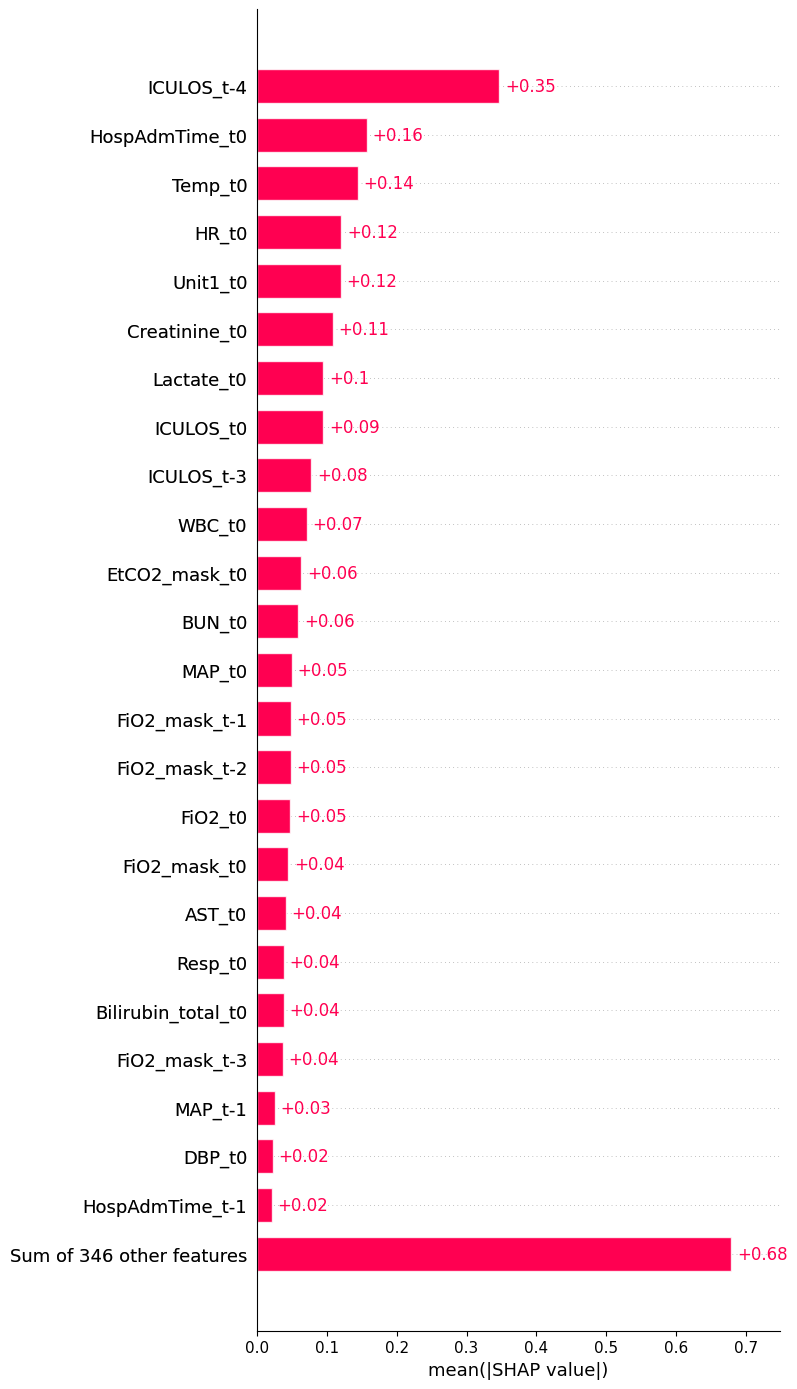

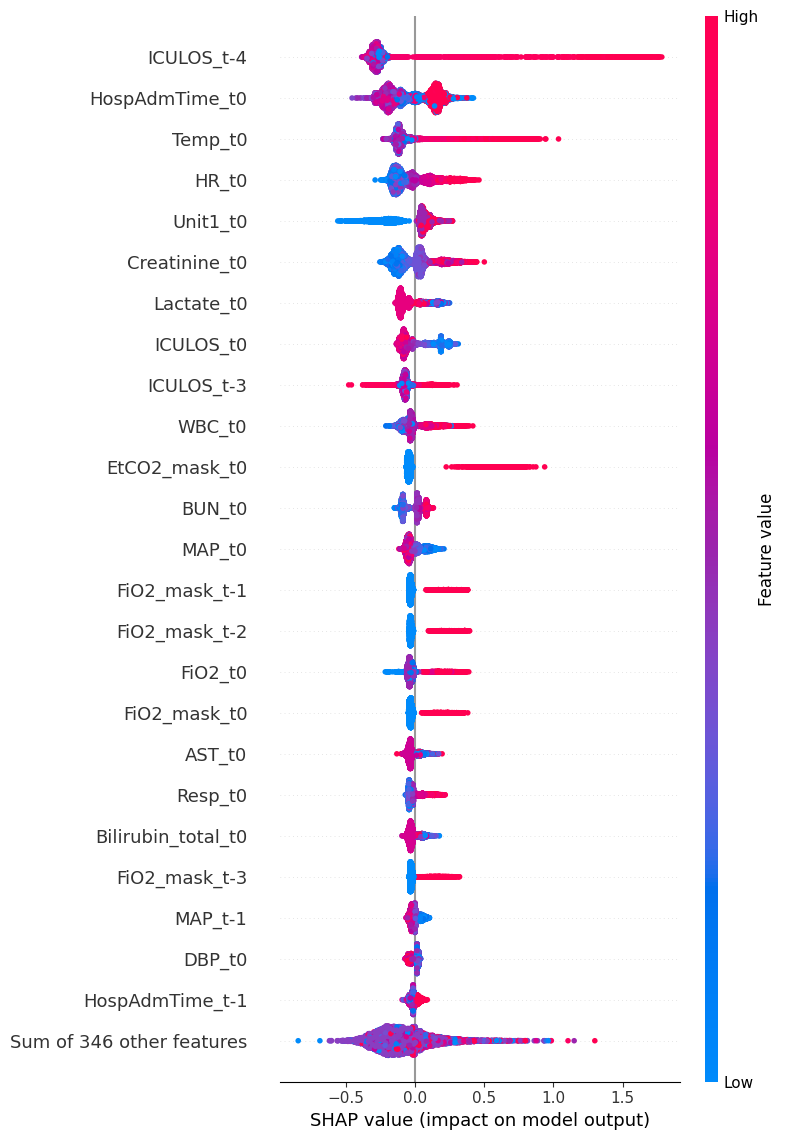

,feature,mean_abs_shap
335,ICULOS_t-4,0.346737
38,HospAdmTime_t0,0.156761
2,Temp_t0,0.143865
0,HR_t0,0.120679
36,Unit1_t0,0.120185
19,Creatinine_t0,0.108371
22,Lactate_t0,0.095056
39,ICULOS_t0,0.094902
261,ICULOS_t-3,0.077611
31,WBC_t0,0.071053


In [ ]:
rng = np.random.default_rng(SEED)
sample_size = min(GLOBAL_SAMPLE_SIZE, len(X))
sample_index = np.sort(rng.choice(len(X), size=sample_size, replace=False))
X_sample = X[sample_index]
dsample = xgb.DMatrix(X_sample, feature_names=FEATURE_NAMES)
contributions = full_model.predict(dsample, pred_contribs=True)
shap_values = contributions[:, :-1]
base_values = contributions[:, -1]
raw_margin = full_model.predict(dsample, output_margin=True)

if not np.allclose(base_values + shap_values.sum(axis=1), raw_margin, atol=1e-3):
    raise RuntimeError("TreeSHAP additivity check failed")

explanation = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_sample,
    feature_names=FEATURE_NAMES,
)
global_importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

shap.plots.bar(explanation, max_display=25, show=False)
plt.tight_layout()
plt.show()
plt.close()

shap.plots.beeswarm(explanation, max_display=25, show=False)
plt.tight_layout()
plt.show()
plt.close()

display(global_importance.head(25))